In [ ]:
print('g')

g


In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d vbookshelf/pneumothorax-chest-xray-images-and-masks

!unzip -q pneumothorax-chest-xray-images-and-masks.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/pneumothorax-chest-xray-images-and-masks
License(s): unknown
100% 4.49G/4.50G [01:10<00:00, 41.4MB/s]
100% 4.50G/4.50G [01:10<00:00, 68.2MB/s]


In [ ]:
! pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 17.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import os
import cv2
import pandas as pd
import pydicom
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K

In [ ]:
df = pd.read_csv('/content/dataset/siim-acr-pneumothorax/stage_1_train_images.csv')

In [ ]:
df.head()

,new_filename,ImageId,has_pneumo
0,0_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5797.151787519...,1
1,1_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5798.151787519...,0
2,2_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5799.151787519...,0
3,3_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.580.1517875163...,0
4,4_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5800.151787519...,0


In [ ]:
df.shape

(10675, 3)

In [ ]:
df.columns

Index(['new_filename', 'ImageId', 'has_pneumo'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   new_filename  1372 non-null   object
 1   ImageId       1372 non-null   object
 2   has_pneumo    1372 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 32.3+ KB


In [ ]:
df['has_pneumo'].value_counts()

,count
has_pneumo,
0,8296
1,2379


In [ ]:

IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 5

images = sorted(glob("/content/dataset/siim-acr-pneumothorax/png_images/*.png"))
masks = sorted(glob("/content/dataset/siim-acr-pneumothorax/png_masks/*.png"))

train_x, val_x, train_y, val_y = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [ ]:
train_x[:5]

['/content/dataset/siim-acr-pneumothorax/png_images/1058_test_1_.png',
 '/content/dataset/siim-acr-pneumothorax/png_images/411_train_1_.png',
 '/content/dataset/siim-acr-pneumothorax/png_images/8243_train_0_.png',
 '/content/dataset/siim-acr-pneumothorax/png_images/4836_train_0_.png',
 '/content/dataset/siim-acr-pneumothorax/png_images/925_train_1_.png']

In [ ]:
import os
import shutil
from tqdm import tqdm

VALID_IMG_DIR = 'validation_dataset/images'
VALID_MASK_DIR = 'validation_dataset/masks'

os.makedirs(VALID_IMG_DIR, exist_ok=True)
os.makedirs(VALID_MASK_DIR, exist_ok=True)

print("Copying validation images...")
for path in tqdm(val_x):
    shutil.copy(path, os.path.join(VALID_IMG_DIR, os.path.basename(path)))

print("Copying validation masks...")
for path in tqdm(val_y):
    shutil.copy(path, os.path.join(VALID_MASK_DIR, os.path.basename(path)))

print(f"\n✅ Done! Total {len(val_x)} image-mask pairs copied.")

Copying validation images...


100%|██████████| 2410/2410 [00:13<00:00, 182.65it/s]


Copying validation masks...


100%|██████████| 2410/2410 [00:00<00:00, 5818.41it/s]


✅ Done! Total 2410 image-mask pairs copied.


In [ ]:

# !zip -r validation_data.zip validation_dataset/

# from google.colab import files
# files.download('validation_data.zip')

### DataGenerator & Augmentation

In [ ]:
## ------------------------------Tensorflow-Choice---------------------------
def parse_data(img_path, mask_path):

    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256])
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask

def sync_augment(img, mask):

    seed = tf.random.experimental.stateless_split(tf.random.uniform([2], maxval=10000, dtype=tf.int32), num=1)[0]

    img = tf.image.stateless_random_flip_left_right(img, seed=seed)
    mask = tf.image.stateless_random_flip_left_right(mask, seed=seed)

    img = tf.image.random_brightness(img, max_delta=0.2)

    return img, mask

def tf_dataset(x, y, batch_size=8, training=True):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    dataset = dataset.map(parse_data, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.map(sync_augment, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


## -----------------------------Opencv-Choice--------------------------------

# def load_and_preprocess_opencv(img_path, mask_path):

    # img_path = img_path.numpy().decode('utf-8')
    # mask_path = mask_path.numpy().decode('utf-8')

    # img = cv2.imread(img_path)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # img = cv2.resize(img, (256, 256))
    # img = img / 255.0  # Normalization

    # mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    # mask = cv2.resize(mask, (256, 256))
    # mask = np.expand_dims(mask, axis=-1)
    # mask = mask / 255.0 # Normalization

    # return img.astype(np.float32), mask.astype(np.float32)

# def sync_augment(img, mask):
    # seed = tf.random.experimental.stateless_split(tf.random.uniform([2], maxval=10000, dtype=tf.int32), num=1)[0]

    # img = tf.image.stateless_random_flip_left_right(img, seed=seed)
    # mask = tf.image.stateless_random_flip_left_right(mask, seed=seed)

    # img = tf.image.random_brightness(img, max_delta=0.2)

    # return img, mask

# def tf_dataset(x, y, batch_size=8, training=True):
    # dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # '''
    #     Creates a TensorFlow dataset from the list of image paths (x) and mask paths (y)
    # '''

    # def map_func(img_path, mask_path):
    #     img, mask = tf.py_function(load_and_preprocess_opencv, [img_path, mask_path], [tf.float32, tf.float32])

    #     img.set_shape((256, 256, 3))
    #     mask.set_shape((256, 256, 1))
    #     return img, mask

    # dataset = dataset.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)

    # if training:
    #     '''
    #         If it's a training set, we apply augment (to prevent overfitting) and shuffle (to randomize the order of images so the model doesn't learn the sequence).
    #     '''
    #     dataset = dataset.map(sync_augment, num_parallel_calls=tf.data.AUTOTUNE)
    #     dataset = dataset.shuffle(buffer_size=1000)

    # dataset = dataset.batch(batch_size)
    # '''
    #     Groups the data into small batches (default is 8). Instead of training 1 image at a time, the model sees 8 images at once, which is more efficient for the GPU.
    # '''
    # dataset = dataset.prefetch(tf.data.AUTOTUNE)
    # '''
    #     This is a crucial step for speed. While the GPU is training on the current batch, the CPU prepares the next batch in the background.
    # '''

    # return dataset


train_dataset = tf_dataset(train_x, train_y, batch_size=BATCH_SIZE, training=True)
val_dataset = tf_dataset(val_x, val_y, batch_size=BATCH_SIZE, training=False)


In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>

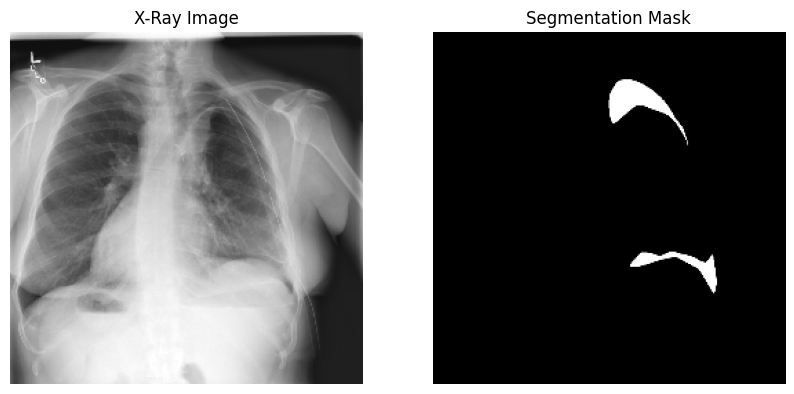

In [ ]:
import matplotlib.pyplot as plt

for images, masks in train_dataset.take(1):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(images[0])
    plt.title("X-Ray Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(masks[0].numpy().squeeze(), cmap='gray')
    plt.title("Segmentation Mask")
    plt.axis("off")

    plt.show()

In [ ]:
def build_resnet50_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # Encoder: ResNet50 (Pre-trained)
    base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

    s1 = base_model.input[0]                               # 256x256
    s2 = base_model.get_layer("conv1_relu").output         # 128x128
    s3 = base_model.get_layer("conv2_block3_out").output   # 64x64
    s4 = base_model.get_layer("conv3_block4_out").output   # 32x32
    bridge = base_model.get_layer("conv4_block6_out").output # 16x16

    def decoder_block(input_tensor, skip_tensor, filters):

        x = layers.UpSampling2D((2, 2))(input_tensor)
        x = layers.Concatenate()([x, skip_tensor])
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        return x

    d1 = decoder_block(bridge, s4, 512)  # 16x16 -> 32x32
    d2 = decoder_block(d1, s3, 256)      # 32x32 -> 64x64
    d3 = decoder_block(d2, s2, 128)      # 64x64 -> 128x128
    d4 = decoder_block(d3, s1, 64)       # 128x128 -> 256x256

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)

    return models.Model(inputs, outputs, name="ResNet50_U-Net")


"Built a Custom U-Net Architecture by integrating a Pre-trained ResNet50 as the Feature Extractor (Encoder), utilizing Skip Connections to recover spatial information for high-resolution medical image segmentation."


# model.compile(optimizer='adam', loss=dice_loss, metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)])

print("Model has been built successfully!")



Model has been built successfully!


In [ ]:

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.0) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.0)

# 1. Dice Loss
def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred)
    return 1 - (numerator + 1) / (denominator + 1)

# 2. Focal Loss
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.mean(K.sum(loss, axis=-1))
    return focal_loss_fixed

# 3.(Dice + Focal)
def total_loss(y_true, y_pred):
    return focal_loss()(y_true, y_pred) + dice_loss(y_true, y_pred)

model = build_resnet50_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=total_loss,
    metrics=[dice_coef, 'accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "ResNet50_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 21,019,905 (80.18 MB)

 Trainable params: 20,987,393 (80.06 MB)

 Non-trainable params: 32,512 (127.00 KB)

In [ ]:
# 1. Reduce Learning Rate on Plateau
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# 2. Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 3. Model Checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_chest_xray_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks_list = [lr_reducer, early_stopping, checkpoint]


history = model.fit(train_dataset, validation_data=val_dataset, epochs=5, callbacks=callbacks_list)


Epoch 1/5
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9424 - dice_coef: 0.1037 - loss: 0.9005
Epoch 1: val_loss improved from inf to 0.82965, saving model to best_chest_xray_model.h5


1205/1205 ━━━━━━━━━━━━━━━━━━━━ 721s 515ms/step - accuracy: 0.9424 - dice_coef: 0.1037 - loss: 0.9005 - val_accuracy: 0.9966 - val_dice_coef: 0.1762 - val_loss: 0.8297 - learning_rate: 1.0000e-04
Epoch 2/5
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9946 - dice_coef: 0.2279 - loss: 0.7767
Epoch 2: val_loss did not improve from 0.82965
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 550s 446ms/step - accuracy: 0.9946 - dice_coef: 0.2279 - loss: 0.7767 - val_accuracy: 0.9963 - val_dice_coef: 0.1280 - val_loss: 0.8782 - learning_rate: 1.0000e-04
Epoch 3/5
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9951 - dice_coef: 0.2556 - loss: 0.7489
Epoch 3: val_loss improved from 0.82965 to 0.79154, saving model to best_chest_xray_model.h5


1205/1205 ━━━━━━━━━━━━━━━━━━━━ 557s 452ms/step - accuracy: 0.9951 - dice_coef: 0.2556 - loss: 0.7489 - val_accuracy: 0.9968 - val_dice_coef: 0.2154 - val_loss: 0.7915 - learning_rate: 1.0000e-04
Epoch 4/5
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9957 - dice_coef: 0.2930 - loss: 0.7114
Epoch 4: val_loss improved from 0.79154 to 0.75262, saving model to best_chest_xray_model.h5


1205/1205 ━━━━━━━━━━━━━━━━━━━━ 555s 450ms/step - accuracy: 0.9957 - dice_coef: 0.2930 - loss: 0.7114 - val_accuracy: 0.9952 - val_dice_coef: 0.2531 - val_loss: 0.7526 - learning_rate: 1.0000e-04
Epoch 5/5
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9961 - dice_coef: 0.3167 - loss: 0.6875
Epoch 5: val_loss improved from 0.75262 to 0.72724, saving model to best_chest_xray_model.h5


1205/1205 ━━━━━━━━━━━━━━━━━━━━ 552s 447ms/step - accuracy: 0.9961 - dice_coef: 0.3167 - loss: 0.6875 - val_accuracy: 0.9969 - val_dice_coef: 0.2802 - val_loss: 0.7272 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.


In [ ]:
val_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>

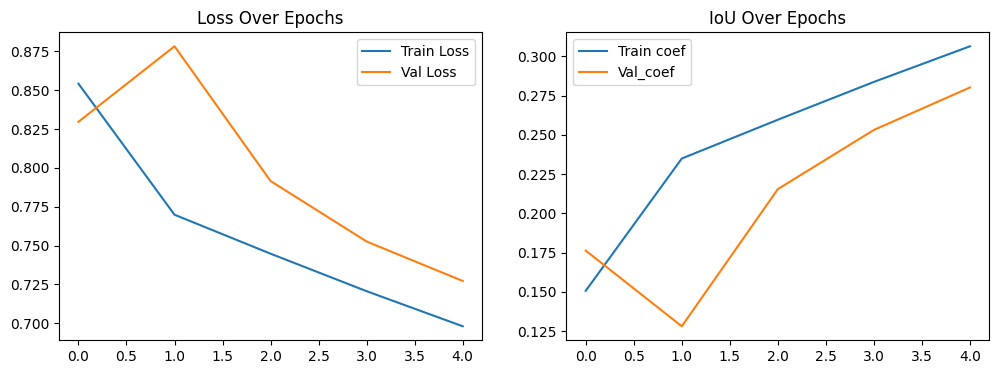

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    # IoU Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['dice_coef'], label='Train coef')
    plt.plot(history.history['val_dice_coef'], label='Val_coef')
    plt.title('IoU Over Epochs')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
def plot_results(img, true_mask, pred_mask):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original X-ray")
    plt.imshow(img)

    plt.subplot(1, 3, 2)
    plt.title("Actual Mask")
    plt.imshow(true_mask, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("AI Prediction")
    plt.imshow(pred_mask > 0.5, cmap='Reds', alpha=0.5) # রেড মাস্ক ওভারলে
    plt.imshow(img, alpha=0.5)

    plt.show()

In [ ]:
!apt-get install graphviz
tf.keras.utils.plot_model(model,to_file='unet_model.png',rankdir='TB')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


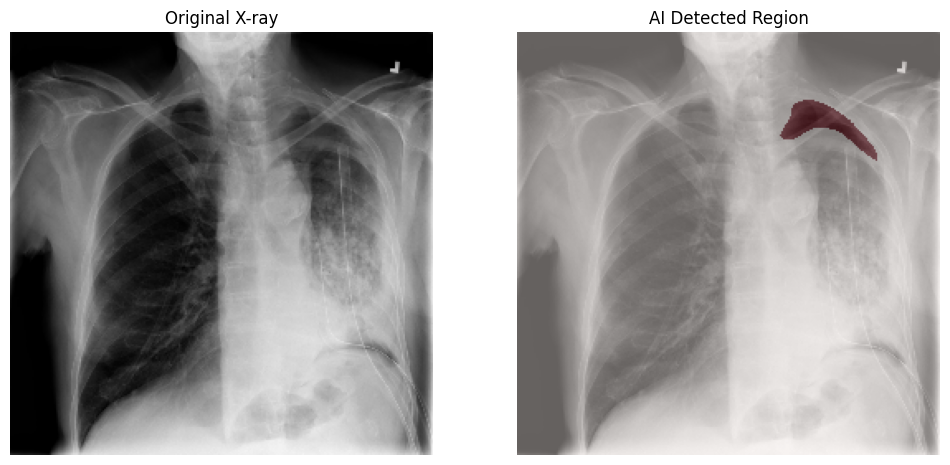

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('best_chest_xray_model.h5', compile=False)

def predict_and_visualize(image_path, img_size=(256, 256)):

    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(original_img, img_size)
    img_input = img_resized / 255.0
    img_input = np.expand_dims(img_input, axis=0)

    prediction = model.predict(img_input)[0]

    mask = (prediction > 0.5).astype(np.uint8)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Original X-ray")
    plt.imshow(img_resized)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("AI Detected Region")
    plt.imshow(img_resized)
    plt.imshow(mask.squeeze(), cmap='Reds', alpha=0.4)
    plt.axis('off')

    plt.show()

predict_and_visualize('/content/dataset/siim-acr-pneumothorax/png_images/0_test_1_.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


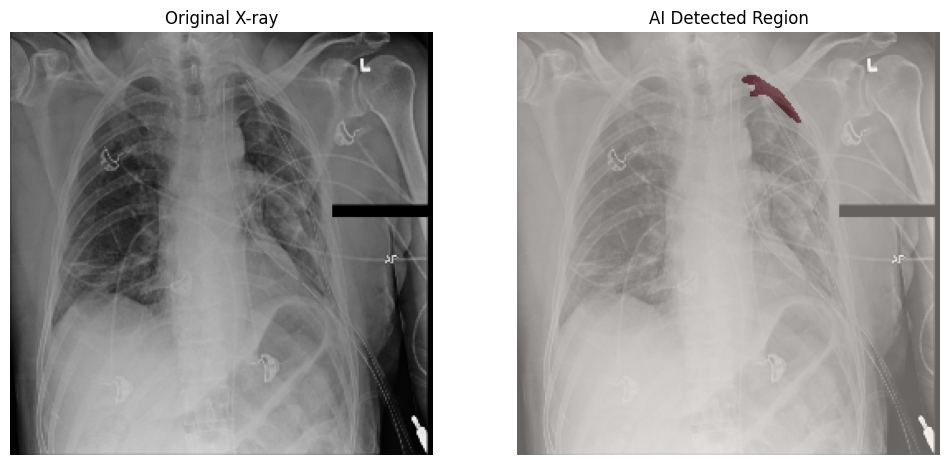

In [ ]:
predict_and_visualize('/content/dataset/siim-acr-pneumothorax/png_images/1086_train_0_.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


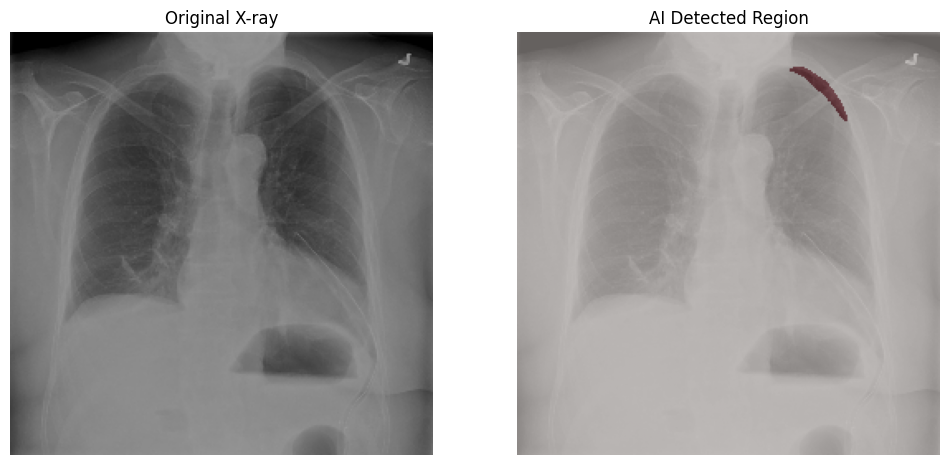

In [ ]:
predict_and_visualize('/content/dataset/siim-acr-pneumothorax/png_images/1090_test_1_.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


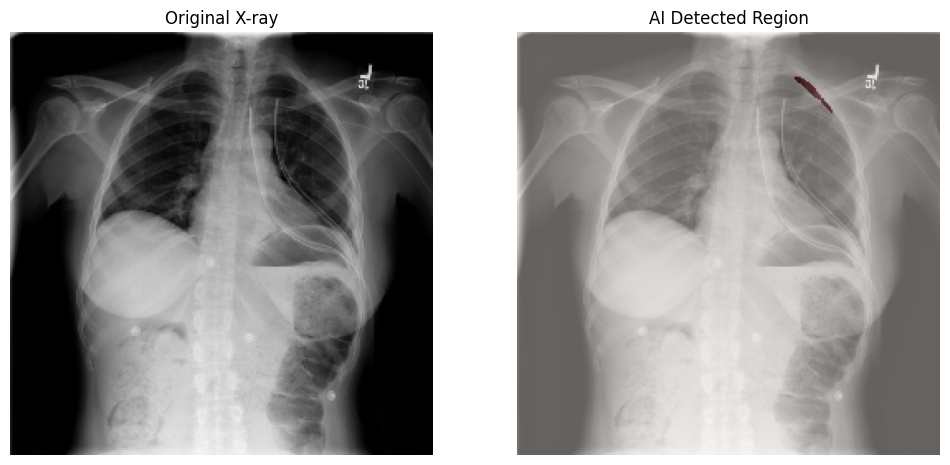

In [ ]:
predict_and_visualize('/content/dataset/siim-acr-pneumothorax/png_images/1011_train_1_.png')

In [ ]:
test_img = '/content/dataset/siim-acr-pneumothorax/png_images/1090_test_1_.png'
img_path = '/content/dataset/siim-acr-pneumothorax/png_images/1090_test_1_.png'

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


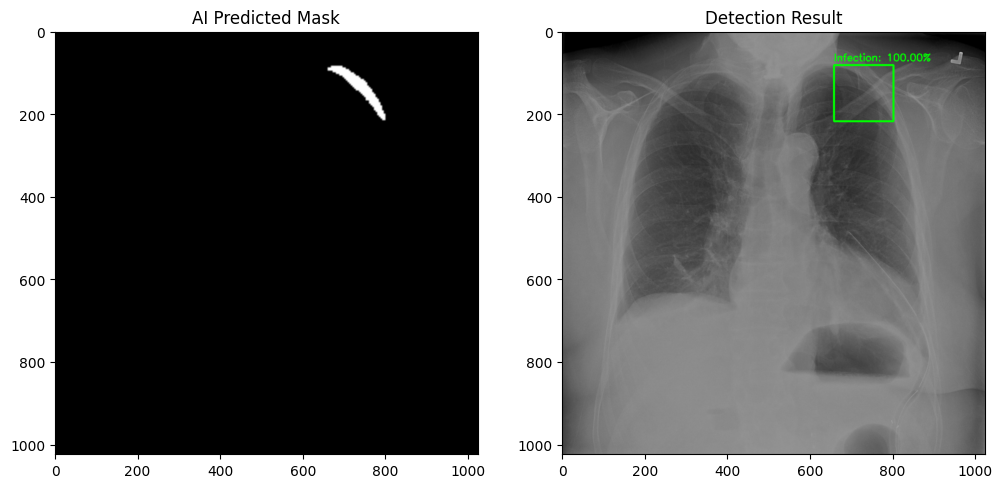

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('best_chest_xray_model.h5', compile=False)
original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

input_img = cv2.resize(original_img, (256, 256)) / 255.0
input_img = np.expand_dims(input_img, axis=0)

pred_mask = model.predict(input_img)[0]
confidence_score = np.max(pred_mask) * 100
binary_mask = (pred_mask > 0.5).astype(np.uint8) * 255
binary_mask = cv2.resize(binary_mask, (original_img.shape[1], original_img.shape[0]))

contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output_img = original_img.copy()
for cnt in contours:
    if cv2.contourArea(cnt) > 500:
        x, y, w, h = cv2.boundingRect(cnt)

        cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 3)

        label = f"Infection: {confidence_score:.2f}%"
        cv2.putText(output_img, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("AI Predicted Mask")
plt.imshow(binary_mask, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Detection Result")
plt.imshow(output_img)
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_boxes_with_confidence(original_img, pred_mask, confidence_score):
    mask_binary = (pred_mask > 0.5).astype(np.uint8) * 255

    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # output_img = original_img.copy()

    for cnt in contours:
        if cv2.contourArea(cnt) > 100:
            x, y, w, h = cv2.boundingRect(cnt)

            cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

            label = f"Infection: {confidence_score:.2f}%"
            cv2.putText(output_img, label, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return output_img


"Implemented post-processing algorithms using OpenCV to extract bounding boxes from segmentation masks and integrated confidence-level scoring for enhanced diagnostic interpretability."

'Implemented post-processing algorithms using OpenCV to extract bounding boxes from segmentation masks and integrated confidence-level scoring for enhanced diagnostic interpretability.'

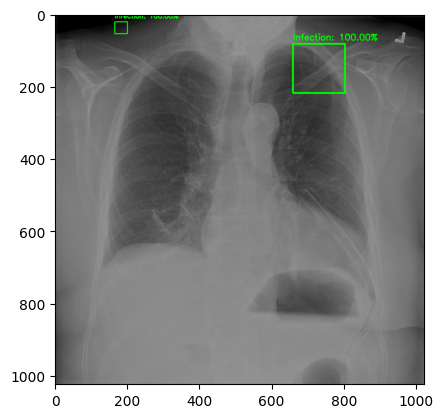

In [ ]:
final_result = draw_boxes_with_confidence(test_img, pred_mask, confidence_score)
plt.imshow(final_result)

In [ ]:
import streamlit as st
import tensorflow as tf
import cv2
import numpy as np
from PIL import Image

st.set_page_config(page_title="AI Chest X-ray Analyzer", layout="wide")
st.title("🩺 AI-Powered Chest X-ray Segmentation")
st.write("Upload a Chest X-ray image, and our AI will detect infected areas with confidence levels.")


@st.cache_resource
def load_segmentation_model():

    return tf.keras.models.load_model('best_chest_xray_model.h5', compile=False)

model = load_segmentation_model()

uploaded_file = st.file_uploader("Choose an X-ray image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:

    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    original_img = cv2.imdecode(file_bytes, 1)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    input_img = cv2.resize(original_img, (256, 256)) / 255.0
    input_img = np.expand_dims(input_img, axis=0)

    with st.spinner('AI is analyzing the X-ray...'):
        pred_mask = model.predict(input_img)[0]

    binary_mask = (pred_mask > 0.5).astype(np.uint8) * 255
    binary_mask = cv2.resize(binary_mask, (original_img.shape[1], original_img.shape[0]))

    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # output_img = original_img.copy()
    found_infection = False

    for cnt in contours:
        if cv2.contourArea(cnt) > 500:
            found_infection = True
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 5)
            confidence = np.max(pred_mask) * 100
            label = f"Confidence: {confidence:.1f}%"
            cv2.putText(output_img, label, (x, y - 15), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Original Image")
        st.image(original_img, use_column_width=True)

    with col2:
        st.subheader("AI Detection Result")
        st.image(output_img, use_column_width=True)

    if found_infection:
        st.error(f"⚠️ Potential abnormality detected with {confidence:.1f}% confidence. Please consult a radiologist.")
    else:
        st.success("✅ No significant abnormalities detected by the AI model.")

st.sidebar.info("Disclaimer: This tool is for educational purposes only and not for medical diagnosis.")

In [ ]:
from google.colab import files

# Path to the downloaded dataset zip file
dataset_zip_path = '/content/pneumothorax-chest-xray-images-and-masks.zip'

# Download the file to your local machine
# files.download(dataset_zip_path)